# Question 1

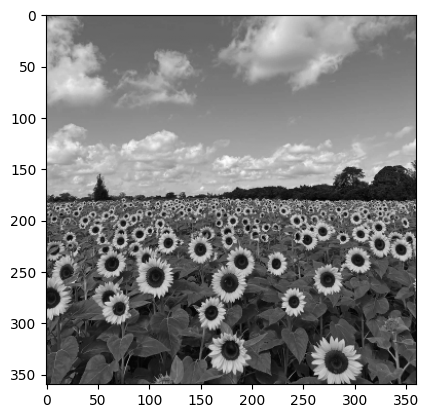

In [14]:
import cv2 as cv
import numpy as np
from scipy.ndimage import gaussian_laplace
import matplotlib.pyplot as plt

im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale and float type for calculations
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
im_gray = im_gray.astype(np.float64)

#show image
plt.imshow(im_gray, cmap='gray')

In [15]:
min_sigma = 10
max_sigma = 40
num_sigma_layers = 10
sigma_values = np.linspace(min_sigma, max_sigma, num_sigma_layers)

print(f"Using sigma range: {min_sigma} to {max_sigma}")

height, width = im_gray.shape

log_scale_space = np.empty((height, width, num_sigma_layers))

print("Building scale-space...")
for i, sigma in enumerate(sigma_values):
    log_image = gaussian_laplace(im_gray, sigma=sigma) * (sigma ** 2)
    log_scale_space[:, :, i] = log_image
print("Scale-space built.")

Using sigma range: 10 to 40
Building scale-space...
Scale-space built.


In [16]:
from skimage.feature import peak_local_max
blobs_log = peak_local_max(-log_scale_space, min_distance=15, threshold_abs=20)
print(f"Detected {len(blobs_log)} potential blobs.")
blobs_log[:, 2] = sigma_values[blobs_log[:, 2]] * np.sqrt(2)

Detected 0 potential blobs.


In [17]:
im_with_circles = im.copy()
sorted_blobs = sorted(blobs_log, key=lambda x: x[2], reverse=True)
for i, blob in enumerate(sorted_blobs[:5]):
    y, x, r = blob
    print(f"Circle #{i+1}: Center=(x={int(x)}, y={int(y)}), Radius={r:.2f}")
    cv.circle(im_with_circles, (int(x), int(y)), int(r), (0, 255, 0), 2)
cv.imwrite('sunflowers_with_circles.jpg', im_with_circles)

True